In [1]:
# all the dependencies
import gymnasium as gym
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.algorithms.algorithm import Algorithm
from ray.tune.logger import pretty_print
import numpy as np
import os
import pandas as pd
import matplotlib as plt

In [2]:
# name of the environment
# Reference: https://gymnasium.farama.org/environments/classic_control/cart_pole/
env_name = "LunarLander-v3"
env = gym.make(env_name, render_mode='human')  # import the Lunar Lander environment

In [3]:
print(env.observation_space)
print(env.action_space)

Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Discrete(4)


In [4]:
env.action_space.sample()

1

In [4]:
# use the restored agent in the environment
for i in range(10):
    observation, info = env.reset()
    terminated = False
    truncated = False
    score = 0
    j = 0
    while not terminated or truncated:
        j+= 1
        action = env.action_space.sample() # random action
        observation, reward, terminated, truncated, info = env.step(action)
        score += reward
        
        if (score>199):
            truncated = True

        if (j>1000):
            truncated = True
    print("score:",score)
env.close()

score: -184.69449766189666
score: -57.771290760460914
score: -144.1565969798525
score: -401.63360839928066
score: -219.0867258202622
score: -93.5239410458021
score: -187.40513355957995
score: -281.3398519042704
score: -122.68716412624659
score: -80.5086796944381


In [ ]:
# Configuring an Agent: This agent use Defatlt settings from RayRLlib 
# Name: agent_default

config = (
    # The RL algorithm
    PPOConfig()                       
    # The gym Env
    .environment(env_name)
)

#Building the agent with the configurations mentioned above
agent = config.build()

2025-06-18 17:42:43,759	WARNING deprecation.py:50 -- DeprecationWarning: `build` has been deprecated. Use `AlgorithmConfig.build_algo` instead. This will raise an error in the future!
2025-06-18 17:42:43,762	WARNING algorithm_config.py:5014 -- You are running PPO on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
C:\Users\ritwi\anaconda3\envs\total_robotics\lib\site-packages\ray\rllib\algorithms\algorithm.py:520: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
C:\Users\ritwi\

In [5]:
if os.path.exists('logs/logs') is False:
    columns = ['agent_name','itr_steps','rew_mean','rew_max','rew_min','entropy','entropy_coeff','policy_loss','vf_loss']
    df = pd.DataFrame(columns=columns)
    df.to_csv('logs/logs', index=False)
    print(df)

In [6]:
# Recall the last trained agent
agent_name_list = os.listdir('agents')
agent_name_list_in_int = [int(x) for x in agent_name_list]
last_agent_num = max(agent_name_list_in_int)
check_point = 'agents/' + str(last_agent_num)
agent = Algorithm.from_checkpoint(check_point)

# Recall the log data frame
logs = pd.read_csv('logs/logs')

training_range = 10

for i in range(last_agent_num, (last_agent_num + training_range)):
    # Train the agent
    result = agent.train()
    # Save the agent
    check_point_path_name = 'agents/' + str(i+1)
    agent.save(check_point_path_name)
    # Capture the log    
    #print(pretty_print(result)) # It gives all the parameters regarding the training
    logs.at[i,'agent_name'] = str(i+1)
    logs.at[i,'itr_steps'] = result['num_env_steps_trained_this_iter'] * (i+1)
    logs.at[i,'rew_mean'] = result['episode_reward_mean']
    logs.at[i,'rew_max'] = result['episode_reward_max']
    logs.at[i,'rew_min'] = result['episode_reward_min']
    logs.at[i,'entropy'] = result['info']['learner']['default_policy']['learner_stats']['entropy']
    logs.at[i,'entropy_coeff'] = result['info']['learner']['default_policy']['learner_stats']['entropy_coeff']
    logs.at[i,'policy_loss'] = result['info']['learner']['default_policy']['learner_stats']['policy_loss']
    logs.at[i,'vf_loss'] = result['info']['learner']['default_policy']['learner_stats']['vf_loss']
    
    print(logs)
    logs.to_csv('logs/logs', index=False)

2024-03-22 21:16:37,491	WARNING algorithm_config.py:847 -- You have specified 1 evaluation workers, but your `evaluation_interval` is None! Therefore, evaluation will not occur automatically with each call to `Algorithm.train()`. Instead, you will have to call `Algorithm.evaluate()` manually in order to trigger an evaluation run.
C:\Users\ritwi\anaconda3\envs\RayRLlib\lib\site-packages\ray\rllib\algorithms\algorithm.py:483: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
C:\Users\ritwi\anaconda3\envs\RayRLlib\lib\site-packages\ray\tune\logger\unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `Json

   agent_name  itr_steps   rew_mean  rew_max  rew_min   entropy  \
0         1.0     4000.0   21.31016     78.0      9.0  0.665769   
1         2.0     8000.0   41.69000    126.0     10.0  0.609984   
2         3.0    12000.0   72.44000    321.0     11.0  0.584548   
3         4.0    16000.0  105.85000    500.0     11.0  0.564202   
4         5.0    20000.0  141.20000    500.0     11.0  0.576793   
5         6.0    24000.0  175.45000    500.0     11.0  0.558072   
6         7.0    28000.0  209.04000    500.0     11.0  0.554356   
7         8.0    32000.0  245.36000    500.0     11.0  0.542673   
8         9.0    36000.0  285.89000    500.0     11.0  0.516552   
9        10.0    40000.0  320.59000    500.0     11.0  0.536463   
10         11    44000.0  500.00000    500.0    500.0  0.504260   

    entropy_coeff  policy_loss   vf_loss  
0            0.01    -0.042759  8.912330  
1            0.01    -0.034351  8.943695  
2            0.01    -0.023707  9.573696  
3            0.01    -0

   agent_name  itr_steps    rew_mean  rew_max  rew_min   entropy  \
0         1.0     4000.0   21.310160     78.0      9.0  0.665769   
1         2.0     8000.0   41.690000    126.0     10.0  0.609984   
2         3.0    12000.0   72.440000    321.0     11.0  0.584548   
3         4.0    16000.0  105.850000    500.0     11.0  0.564202   
4         5.0    20000.0  141.200000    500.0     11.0  0.576793   
5         6.0    24000.0  175.450000    500.0     11.0  0.558072   
6         7.0    28000.0  209.040000    500.0     11.0  0.554356   
7         8.0    32000.0  245.360000    500.0     11.0  0.542673   
8         9.0    36000.0  285.890000    500.0     11.0  0.516552   
9        10.0    40000.0  320.590000    500.0     11.0  0.536463   
10         11    44000.0  500.000000    500.0    500.0  0.504260   
11         12    48000.0  500.000000    500.0    500.0  0.538168   
12         13    52000.0  479.240000    500.0    253.0  0.561163   
13         14    56000.0  482.515152    500.0   

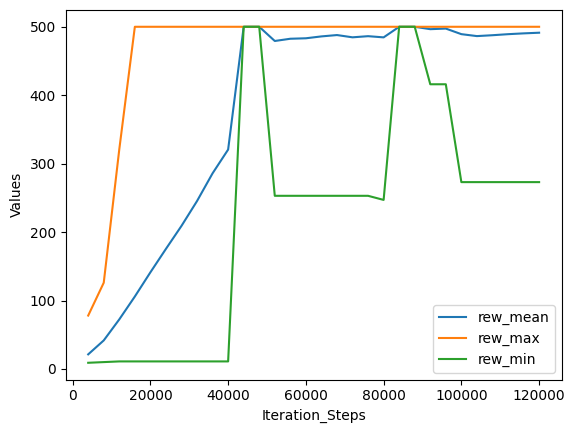

In [2]:
import matplotlib.pyplot as plt
logs = pd.read_csv('logs/logs')

# Plotting Column1 and Column2 with Time as the x-axis
plt.plot(logs['itr_steps'], logs['rew_mean'], label='rew_mean')
plt.plot(logs['itr_steps'], logs['rew_max'], label='rew_max')
plt.plot(logs['itr_steps'], logs['rew_min'], label='rew_min')

# Adding labels and legend
plt.xlabel('Iteration_Steps')
plt.ylabel('Values')
plt.legend()

# Display the plot
plt.show()


In [5]:
# recall and trained agent
check_point = "agents/10"
agent = Algorithm.from_checkpoint(check_point)

ArrowInvalid: URI has empty scheme: 'agents/10'

In [11]:
# use the restored agent in the environment
env = gym.make("CartPole-v1", render_mode='human')
for j in range(20):
    observation = np.array(env.reset()[0])
    done = False
    score = 0
    while not done:
        action = agent.compute_single_action(observation) # here is the RL agent from RAYRLlib
        observation,reward,done,info,info = env.step(action)
        score += reward
        if (score>1000):
            done = True
    print("score:",score)
env.close()

C:\Users\ritwi\anaconda3\envs\RayRLlib\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0
score: 1001.0


In [14]:
result

{'custom_metrics': {},
 'episode_media': {},
 'info': {'learner': {'default_policy': {'learner_stats': {'cur_kl_coeff': 0.0023437500931322575,
     'cur_lr': 4.999999873689376e-05,
     'total_loss': 9.750219,
     'policy_loss': -0.01726467,
     'vf_loss': 9.772765,
     'vf_explained_var': -0.19277616,
     'kl': 0.0038644737,
     'entropy': 0.5289961,
     'entropy_coeff': 0.009999999776482582,
     'model': {}},
    'custom_metrics': {},
    'num_agent_steps_trained': 128.0,
    'num_grad_updates_lifetime': 8835.5,
    'diff_num_grad_updates_vs_sampler_policy': 464.5}},
  'num_env_steps_sampled': 80000,
  'num_env_steps_trained': 80000,
  'num_agent_steps_sampled': 80000,
  'num_agent_steps_trained': 80000},
 'sampler_results': {'episode_reward_max': 500.0,
  'episode_reward_min': 247.0,
  'episode_reward_mean': 484.5243902439024,
  'episode_len_mean': 484.5243902439024,
  'episode_media': {},
  'episodes_this_iter': 8,
  'policy_reward_min': {},
  'policy_reward_max': {},
  'pol

In [2]:
!pip install -U ipywidgets

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 3.4 MB/s eta 0:00:01
   ----------------------- ---------------- 1.3/2.2 MB 3.5 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 2.7 MB/s eta 0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]



In [16]:
!pip install swig
!pip install "gymnasium[box2d]

   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.6 MB 3.3 MB/s eta 0:00:05
   --- ------------------------------------ 1.3/14.6 MB 3.5 MB/s eta 0:00:04
   ----- ---------------------------------- 2.1/14.6 MB 3.4 MB/s eta 0:00:04
   ------- -------------------------------- 2.9/14.6 MB 3.5 MB/s eta 0:00:04
   --------- ------------------------------ 3.4/14.6 MB 3.3 MB/s eta 0:00:04
   ---------- ----------------------------- 3.7/14.6 MB 3.0 MB/s eta 0:00:04
   ----------- ---------------------------- 4.2/14.6 MB 3.1 MB/s eta 0:00:04
   ------------- -------------------------- 5.0/14.6 MB 2.9 MB/s eta 0:00:04
   --------------- ------------------------ 5.5/14.6 MB 2.8 MB/s eta 0:00:04
   --------------- ------------------------ 5.8/14.6 MB 2.8 MB/s eta 0:00:04
   ------------------ --------------------- 6.8/14.6 MB 2.9 MB/s eta 0:00:03
   ---------------------- ----------------- 8.4/14.6 MB 3.3 MB/s eta 0:00:02
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
genesis-world 0.2.1 requires numpy>=1.26.4, but you have numpy 1.23.5 which is incompatible.
moviepy 2.1.2 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
tetgen 0.6.5 requires numpy<3,>=2, but you have numpy 1.23.5 which is incompatible.
